# Reinforcement Learning Execution Agent
## <b> Adrián Vazquez </b>

---

## Objective

In the previous sections, the project evolved from:
- classical execution schedules,
- stochastic execution simulation,
- and real intraday execution analysis,

toward a realistic market execution environment incorporating market microstructure dynamics.

The next step is to move beyond static execution rules and explore whether an agent can learn adaptive execution behavior directly from market state information.

The central research question of this section is:

> Can a Reinforcement Learning agent learn when to execute more aggressively or more passively depending on liquidity, volatility, inventory pressure, and remaining execution time?

---

## Motivation

Traditional execution strategies such as:
- TWAP,
- VWAP,
- and Almgren–Chriss

follow predefined execution rules.

However, real financial markets are dynamic:
- liquidity changes intraday,
- volatility fluctuates,
- participation impacts execution quality,
- and optimal decisions depend on current market conditions.

Reinforcement Learning provides a framework for modeling execution as a sequential decision-making problem under uncertainty.

Instead of manually defining execution schedules, the agent learns execution behavior through interaction with the market environment.

---

## Methodology Overview

The RL framework developed in this section follows the pipeline:

```text
Market State
    ↓
DQN Agent
    ↓
Execution Action
    ↓
Execution Environment
    ↓
Reward Signal
    ↓
Policy Improvement
```

The agent observes:
- remaining inventory,
- time remaining,
- liquidity conditions,
- volatility dynamics,
- and market microstructure features,

and learns an execution policy through repeated interaction with the environment.

---

## Core Components

This section focuses on:

1. Deep Q-Network (DQN) architecture  
2. Experience replay memory  
3. Epsilon-greedy exploration  
4. Sequential execution learning  
5. Policy evaluation against benchmark strategies  

---

## Benchmark Comparison

The learned RL policy will be compared against:
- Random execution,
- TWAP,
- VWAP-like execution,
- Volume-Aware Almgren–Chriss.

Performance evaluation will focus on:
- cumulative execution cost,
- inventory trajectories,
- participation dynamics,
- execution stability,
- and liquidity sensitivity.

---

## Expected Outcome

The goal is not necessarily to outperform every benchmark under all market conditions.

Instead, the objective is to evaluate whether the RL agent can learn financially coherent adaptive execution behavior under realistic market microstructure dynamics.

In [1]:
# libs
import plotly.io as pio
#pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))

# libs 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.models.inventory_from_schedule import inventory_from_schedule
from src.models.almgren_chriss_shedule import almgren_chriss_schedule
from src.analytics.implementation_shortfall import implementation_shortfall
from src.analytics.get_intraday_prices import get_intraday_prices
from src.models.simulate_brownian_motion_price_path import simulate_brownian_price_path, simulate_multiple_price_paths, simulate_execution_prices
from src.models.volume_aware_ac_schedule import volume_aware_ac_schedule

# **1. Data Acquisition**

## Cleaning
* **Sort index**
* **Remove duplicates**
* **Keep regular market hours**
* **Datetime formatting**

## Market Feature Engineering
* **Returns**
* **Rolling vol**
* **Rel volume**
* **Momentum**
* **Spread proxy pct**
* **Volume profile norm**

## Final RL Dataset
* **StateBuilder input**
* **Environment bases**

---

## State Representation

The reinforcement learning agent does not observe raw prices alone.

Instead, the environment state is divided into two components:

$$
s_t =
[
\text{execution state},
\text{market state}
]
$$

---

### 1. Execution State

The execution state represents the current liquidation problem faced by the agent.

It captures:
- remaining inventory,
- execution urgency.

Formally:

$$
\left[
\frac{x_t}{Q},
\frac{T-t}{T}
\right]
$$

Where:
- $( x_t)$ = remaining inventory
- $( Q ) $= total parent order size
- $( T )$ = total execution horizon

Interpretation:
- $ \frac{x_t}{Q} $ measures how much inventory remains to be executed.
- $ \frac{T-t}{T} $ measures how much time remains before the execution horizon ends.

---

### 2. Market State

The market state captures observable market microstructure conditions.

Current features include:
- relative volume,
- rolling intraday volatility,
- momentum,
- spread proxy,
- normalized intraday volume profile.

These variables allow the agent to observe:
- liquidity conditions,
- volatility dynamics,
- directional pressure,
- execution frictions,
- intraday market behavior.

---

### Complete State Vector

The final state vector used by the agent is:

$$
s_t =
[
\underbrace{
\frac{x_t}{Q},
\frac{T-t}{T}
}_{\text{execution state}},
\underbrace{
\text{rel\_volume},
\text{rolling\_vol},
\text{momentum},
\text{spread\_proxy},
\text{volume\_profile}
}_{\text{market state}}
]
$$

This representation allows the execution agent to jointly reason about:
- inventory pressure,
- remaining execution time,
- and current market conditions.

In [4]:
#  Download intraday market data


API_KEY = "M617ZETAG1ZHY6I6"

df_spy_5min = get_intraday_prices(
    symbol="SPY",
    api_key=API_KEY,
    interval="5min",
    outputsize="full",
    extended_hours="false",
    adjusted=False
)

# Cleaning

df_spy_5min.index = pd.to_datetime(df_spy_5min.index)

df_spy_5min = (
    df_spy_5min
    .sort_index()
    .loc[~df_spy_5min.index.duplicated()]
)

df_spy_5min = df_spy_5min.between_time("09:30", "15:55")


# Market feature engineering


df_market_state = df_spy_5min.copy()

# Price dynamics
df_market_state["returns"] = df_market_state["Close"].pct_change()

df_market_state["rolling_vol"] = (
    df_market_state["returns"]
    .rolling(window=20)
    .std()
)

df_market_state["momentum"] = (
    df_market_state["Close"]
    - df_market_state["Close"].rolling(window=5).mean()
)

# Liquidity dynamics
df_market_state["rel_volume"] = (
    df_market_state["Volume"]
    / df_market_state["Volume"].rolling(window=20).mean()
)

df_market_state["minute_of_day"] = (
    df_market_state.index.hour * 60
    + df_market_state.index.minute
)

volume_profile = (
    df_market_state
    .groupby("minute_of_day")["Volume"]
    .mean()
)

df_market_state["volume_profile"] = (
    df_market_state["minute_of_day"]
    .map(volume_profile)
)

df_market_state["volume_profile_norm"] = (
    df_market_state["volume_profile"]
    / df_market_state["volume_profile"].mean()
)

# Friction proxy
df_market_state["spread_proxy"] = (
    df_market_state["High"]
    - df_market_state["Low"]
)

df_market_state["spread_proxy_pct"] = (
    df_market_state["spread_proxy"]
    / df_market_state["Close"]
)

# Final RL market state dataset

market_feature_cols = [
    "returns",
    "rolling_vol",
    "momentum",
    "rel_volume",
    "volume_profile_norm",
    "spread_proxy_pct"
]

df_market_state = df_market_state.dropna(
    subset=market_feature_cols
)

print("Market state dataset shape:", df_market_state.shape)
print("Start:", df_market_state.index.min())
print("End:", df_market_state.index.max())

df_market_state[market_feature_cols].head()

Market state dataset shape: (1696, 14)
Start: 2026-04-22 11:10:00
End: 2026-05-21 15:55:00


,returns,rolling_vol,momentum,rel_volume,volume_profile_norm,spread_proxy_pct
2026-04-22 11:10:00,-0.000035,0.000550,0.027,0.510958,0.725822,0.000589
2026-04-22 11:15:00,0.000099,0.000541,0.095,0.585845,0.940085,0.000592
2026-04-22 11:20:00,0.000394,0.000539,0.345,1.179356,0.842178,0.000845
2026-04-22 11:25:00,0.000014,0.000538,0.199,1.039370,0.994151,0.001028
2026-04-22 11:30:00,-0.000169,0.000519,0.036,0.495447,0.848181,0.000620


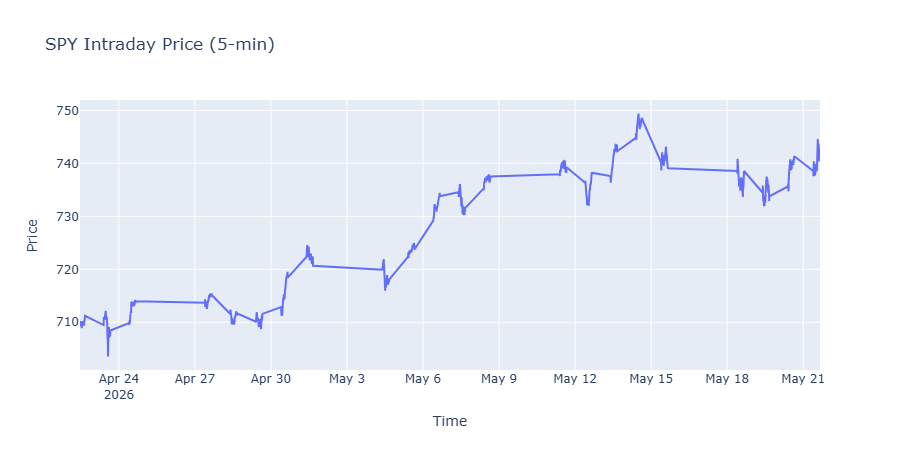

In [5]:
# plot
df_spy_5min = df_market_state.copy()
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df_spy_5min.index,
        y=df_spy_5min["Close"],
        mode="lines",
        name="SPY Close"
    )
)
fig.update_layout(
    title="SPY Intraday Price (5-min)",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=900
)
fig.show()
fig.write_image("../results/plots/2_SPY_Intraday_Price_5min.png")
display(Image(filename="../results/plots/2_SPY_Intraday_Price_5min.png"))

# <b> 2.  StateBuilder from `04_Reiforcment_Learning_execution.ipynb` </b>

In [6]:
class StateBuilder:
    def __init__(self, market_data, feature_cols):
        self.market_data = market_data.reset_index(drop=True).copy()
        self.feature_cols = feature_cols

    def build_state(self, t, inventory_remaining, order_size):
        """
        Build the RL state vector at timestep t.

        State:
        [
            inventory_remaining / order_size,
            time_remaining / total_steps,
            rel_volume_t,
            rolling_vol_t,
            spread_proxy_pct_t,
            momentum_t
        ]
        """

        total_steps = len(self.market_data)

        inventory_ratio = inventory_remaining / order_size
        time_remaining = (total_steps - t - 1) / total_steps

        market_features = (
            self.market_data
            .loc[t, self.feature_cols]
            .values
            .astype(np.float32)
        )

        state = np.concatenate([
            np.array(
                [inventory_ratio, time_remaining],
                dtype=np.float32
            ),
            market_features
        ])

        return state

In [7]:
state_features = [
    "returns",
    "rolling_vol",
    "momentum",
    "rel_volume",
    "volume_profile_norm",
    "spread_proxy_pct"
]

state_builder = StateBuilder(
    market_data=df_market_state,
    feature_cols=state_features
)

Q = 100_000
inventory_remaining = 60_000
t = 10

state_t = state_builder.build_state(
    t=t,
    inventory_remaining=inventory_remaining,
    order_size=Q
)

state_t

array([6.0000002e-01, 9.9351418e-01, 3.5229130e-04, 5.4227642e-04,
       2.3999999e-01, 9.2586607e-01, 6.0395128e-01, 7.7476795e-04],
      dtype=float32)

# <b> 3. Execution Environment from  `04_Reiforcment_Learning_execution.ipynb`  </b>

In [8]:
class ExecutionEnv:
    def __init__(
        self,
        market_data,
        state_builder,
        order_size=100_000,
        action_space=None,
        eta=0.05,
        inventory_penalty=1e-10,
        participation_penalty=1e-2,
        terminal_penalty=1e-6
    ):
        self.market_data = market_data.reset_index(drop=True).copy()
        self.state_builder = state_builder
        self.order_size = order_size

        self.action_space = action_space or  np.linspace(0.00,0.05,51).tolist()

        self.eta = eta
        self.inventory_penalty = inventory_penalty
        self.participation_penalty = participation_penalty
        self.terminal_penalty = terminal_penalty

        self.total_steps = len(self.market_data)

        self.reset()

    def reset(self):
        self.t = 0
        self.inventory_remaining = self.order_size
        self.arrival_price = float(self.market_data.loc[0, "Close"])

        self.cumulative_cost = 0.0
        self.execution_history = []

        state = self.state_builder.build_state(
            t=self.t,
            inventory_remaining=self.inventory_remaining,
            order_size=self.order_size
        )

        return state

    def step(self, action_idx):
        action_fraction = self.action_space[action_idx]

        price = float(self.market_data.loc[self.t, "Close"])
        volume = float(self.market_data.loc[self.t, "Volume"])

        volume = max(volume, 1.0)

        # Force liquidation at final step
        is_last_step = self.t == self.total_steps - 1

        if is_last_step:
            shares_to_trade = self.inventory_remaining
        else:
            shares_to_trade = action_fraction * self.order_size

        shares_to_trade = min(shares_to_trade, self.inventory_remaining)

        participation_rate = shares_to_trade / volume

        # Temporary market impact model
        execution_price = price + self.eta * participation_rate

        # Implementation shortfall-style cost
        step_cost = shares_to_trade * (execution_price - self.arrival_price)

        self.cumulative_cost += step_cost

        # Update inventory
        self.inventory_remaining -= shares_to_trade

        # Reward as negative penalty
        reward = -step_cost
        reward -= self.inventory_penalty * (self.inventory_remaining ** 2)
        reward -= self.participation_penalty * (participation_rate ** 2)

        # Terminal penalty if inventory remains
        if is_last_step and self.inventory_remaining > 0:
            reward -= self.terminal_penalty * (self.inventory_remaining ** 2)

        self.execution_history.append({
            "t": self.t,
            "price": price,
            "volume": volume,
            "action_fraction": action_fraction,
            "shares_traded": shares_to_trade,
            "inventory_remaining": self.inventory_remaining,
            "participation_rate": participation_rate,
            "execution_price": execution_price,
            "step_cost": step_cost,
            "cumulative_cost": self.cumulative_cost,
            "reward": reward
        })

        self.t += 1

        done = (
            self.t >= self.total_steps
            or self.inventory_remaining <= 0
        )

        if done:
            next_state = np.zeros_like(
                self.state_builder.build_state(
                    t=0,
                    inventory_remaining=self.order_size,
                    order_size=self.order_size
                )
            )
        else:
            next_state = self.state_builder.build_state(
                t=self.t,
                inventory_remaining=self.inventory_remaining,
                order_size=self.order_size
            )

        info = {
            "t": self.t,
            "inventory_remaining": self.inventory_remaining,
            "cumulative_cost": self.cumulative_cost,
            "participation_rate": participation_rate,
            "shares_traded": shares_to_trade,
            "execution_price": execution_price
        }

        return next_state, reward, done, info

    def get_execution_history(self):
        return pd.DataFrame(self.execution_history)

df_market_state como un solo episodio. Conviene que cada episodio sea un día intradía. 
al usar la clase es con `df_day`

In [9]:
df_market_state["date"] = df_market_state.index.date

selected_day = df_market_state["date"].max()

df_day = (
    df_market_state[df_market_state["date"] == selected_day]
    .drop(columns=["date"])
    .copy()
)

state_builder_day = StateBuilder(
    market_data=df_day,
    feature_cols=state_features
)

env = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder_day,
    order_size=100_000,
    eta=0.05,
    inventory_penalty=1e-10,
    participation_penalty=1e-2,
    terminal_penalty=1e-6
)

In [10]:
state = env.reset()
done = False

while not done:
    action_idx = np.random.choice(len(env.action_space))
    next_state, reward, done, info = env.step(action_idx)
    state = next_state

history_random = env.get_execution_history()

history_random.head()

,t,price,volume,action_fraction,shares_traded,inventory_remaining,participation_rate,execution_price,step_cost,cumulative_cost,reward
0,0,738.56,1087119.0,0.016,1600.0,98400.0,0.001472,738.560074,0.117742,0.117742,-1.085998
1,1,737.68,667261.0,0.048,4800.0,93600.0,0.007194,737.680360,-4222.273539,-4222.155797,4221.397443
2,2,737.65,506649.0,0.019,1900.0,91700.0,0.003750,737.650188,-1728.643738,-5950.799534,1727.802848
3,3,737.58,700009.0,0.021,2100.0,89600.0,0.003000,737.580150,-2057.685004,-8008.484538,2056.882188
4,4,739.63,1009436.0,0.023,2300.0,87300.0,0.002279,739.630114,2461.262028,-5547.222511,-2462.024157


In [13]:
history_random.tail()

,t,price,volume,action_fraction,shares_traded,inventory_remaining,participation_rate,execution_price,step_cost,cumulative_cost,reward
37,37,738.71,315833.0,0.024,2400.0,6700.0,0.007599,738.710380,360.911874,23546.952683,-360.916364
38,38,738.90,162127.0,0.016,1600.0,5100.0,0.009869,738.900493,544.789505,24091.742187,-544.792106
39,39,738.47,288995.0,0.041,4100.0,1000.0,0.014187,738.470709,-366.091645,23725.650542,366.091543
40,40,738.61,218444.0,0.009,900.0,100.0,0.004120,738.610206,45.185402,23770.835944,-45.185403
41,41,738.90,237301.0,0.015,100.0,0.0,0.000421,738.900021,34.002107,23804.838051,-34.002107


## <b> microstructure-aware RL execution environment </b>

In [ ]:

print("Total shares traded:", history_random["shares_traded"].sum())
print("Final inventory:", history_random["inventory_remaining"].iloc[-1])
print("Number of steps:", len(history_random))
print("Average participation:", history_random["participation_rate"].mean())
print("Max participation:", history_random["participation_rate"].max())

Total shares traded: 100000.0
Final inventory: 0.0
Number of steps: 42
Average participation: 0.00744156904168312
Max participation: 0.021628586548859897


# <b> 4.  BenchMark Policies </b> 

Before training the DQN agent, we define benchmark execution policies under the same market environment.

These benchmarks provide reference execution behavior against which the learned policy will be evaluated:

- Random Policy: naive baseline
- TWAP: time-based execution
- VWAP-like: liquidity-aware execution
- Volume-Aware Almgren–Chriss: model-based liquidity-aware optimal execution

The DQN agent will later be evaluated against these policies using cumulative execution cost, participation dynamics, inventory trajectories, and execution stability.


In [16]:
def run_random_policy(env, seed=42):
    np.random.seed(seed)
    
    state = env.reset()
    done = False
    
    while not done:
        action_idx = np.random.choice(len(env.action_space))
        next_state, reward, done, info = env.step(action_idx)
        state = next_state
    
    history = env.get_execution_history()
    history["policy"] = "Random"
    
    return history


def run_twap_policy(env):
    state = env.reset()
    done = False
    
    while not done:
        inventory_remaining = env.inventory_remaining
        steps_remaining = env.total_steps - env.t
        
        target_shares = inventory_remaining / steps_remaining
        
        # action is fraction of total parent order
        action_fraction = target_shares / env.order_size
        
        action_idx = np.argmin(
            np.abs(np.array(env.action_space) - action_fraction)
        )
        
        next_state, reward, done, info = env.step(action_idx)
        state = next_state
    
    history = env.get_execution_history()
    history["policy"] = "TWAP"
    
    return history


def run_vwap_like_policy(env):
    state = env.reset()
    done = False
    
    while not done:
        inventory_remaining = env.inventory_remaining
        
        volume_now = env.market_data.loc[env.t, "Volume"]
        volume_remaining = env.market_data.loc[env.t:, "Volume"].sum()
        
        target_shares = inventory_remaining * (
            volume_now / volume_remaining
        )
        
        # action is fraction of total parent order
        action_fraction = target_shares / env.order_size
        
        action_idx = np.argmin(
            np.abs(np.array(env.action_space) - action_fraction)
        )
        
        next_state, reward, done, info = env.step(action_idx)
        state = next_state
    
    history = env.get_execution_history()
    history["policy"] = "VWAP-like"
    
    return history


def run_volume_aware_ac_policy(
    env,
    risk_aversion=1.0,
    volume_weight=0.7
):
    """
    Volume-Aware Almgren-Chriss inspired policy.

    Combines:
    - time urgency
    - remaining inventory
    - relative liquidity

    The policy increases execution when volume is high
    and slows down when volume is low.
    """

    state = env.reset()
    done = False

    while not done:
        inventory_remaining = env.inventory_remaining
        steps_remaining = env.total_steps - env.t

        volume_now = env.market_data.loc[env.t, "Volume"]
        volume_remaining = env.market_data.loc[env.t:, "Volume"].sum()

        # TWAP component
        twap_target = inventory_remaining / steps_remaining

        # VWAP liquidity component
        vwap_target = inventory_remaining * (
            volume_now / volume_remaining
        )

        # Volume-aware AC-style blend
        target_shares = (
            (1 - volume_weight) * twap_target
            + volume_weight * vwap_target
        )

        # Risk aversion adjustment
        urgency_multiplier = 1 + risk_aversion * (
            1 / steps_remaining
        )

        target_shares = target_shares * urgency_multiplier

        # Convert target shares to action fraction of total parent order
        action_fraction = target_shares / env.order_size

        action_idx = np.argmin(
            np.abs(np.array(env.action_space) - action_fraction)
        )

        next_state, reward, done, info = env.step(action_idx)
        state = next_state

    history = env.get_execution_history()
    history["policy"] = "VA-AC"

    return history

In [17]:
env_random = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder,
    order_size=100_000
)

env_twap = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder,
    order_size=100_000
)

env_vwap = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder,
    order_size=100_000
)

env_va_ac = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder_day,
    order_size=100_000,
    eta=0.05,
    inventory_penalty=1e-10,
    participation_penalty=1e-2,
    terminal_penalty=1e-6
)



history_random = run_random_policy(env_random)
history_twap = run_twap_policy(env_twap)
history_vwap = run_vwap_like_policy(env_vwap)
history_va_ac = run_volume_aware_ac_policy(
    env_va_ac,
    risk_aversion=1.0,
    volume_weight=0.7
)


## <b> Summary BenchMarks </b>

In [18]:
summary_benchmarks = pd.DataFrame({
    "policy": [
        "Random",
        "TWAP",
        "VWAP-like", 
        'V-A_AC'
    ],
    "cumulative_cost": [
        history_random["cumulative_cost"].iloc[-1],
        history_twap["cumulative_cost"].iloc[-1],
        history_vwap["cumulative_cost"].iloc[-1], 
        history_va_ac["cumulative_cost"].iloc[-1]
    ],
    "total_shares_traded": [
        history_random["shares_traded"].sum(),
        history_twap["shares_traded"].sum(),
        history_vwap["shares_traded"].sum(),
        history_va_ac["shares_traded"].sum()
    ],
    "final_inventory": [
        history_random["inventory_remaining"].iloc[-1],
        history_twap["inventory_remaining"].iloc[-1],
        history_vwap["inventory_remaining"].iloc[-1], 
        history_va_ac["inventory_remaining"].iloc[-1]
    ],
    "avg_participation": [
        history_random["participation_rate"].mean(),
        history_twap["participation_rate"].mean(),
        history_vwap["participation_rate"].mean(), 
        history_va_ac["participation_rate"].mean()

    ],
    "max_participation": [
        history_random["participation_rate"].max(),
        history_twap["participation_rate"].max(),
        history_vwap["participation_rate"].max(), 
        history_va_ac["participation_rate"].max()
    ],
    "num_steps": [
        len(history_random),
        len(history_twap),
        len(history_vwap),
        len(history_va_ac)
    ]
})

summary_benchmarks

,policy,cumulative_cost,total_shares_traded,final_inventory,avg_participation,max_participation,num_steps
0,Random,32766.386244,100000.0,0.0,0.007753,0.023847,40
1,TWAP,192481.600388,100000.0,0.0,0.003537,0.008018,78
2,VWAP-like,226706.290683,100000.0,0.0,0.002629,0.002838,78
3,V-A_AC,214707.364118,100000.0,0.0,0.002986,0.004318,78
